# 09 · Transformer: Attention을 학습 가능한 블록으로 조합하기

**이번 질문:** Attention 하나에 위치, 여러 비교 공간, 정규화, 잔차, 위치별 MLP를 붙이면 전체 backward는 어떻게 연결될까요?

08번의 attention은 부품 하나였습니다. 이번에는 그 부품에 토큰마다의 정규화(LayerNorm), 비교 공간을 나눈 여러 head, 원래 입력을 그대로 더하는 잔차, 위치마다 같은 MLP(FFN), 그리고 정수 토큰을 벡터로 바꾸는 embedding과 위치 표를 붙입니다.
**한 블록의 Pre-LayerNorm Transformer**를 NumPy로 구현하고, 각 부품과 전체의 미분을 검사한 뒤, 길이 4 토큰열을 뒤집는 지도학습을 진행합니다.

- 준비물: [08](08_attention.ipynb)의 Q·K·V와 mask, [03](../00_기초/03_perceptron_to_mlp.ipynb)의 MLP backward, [02](../00_기초/02_probability_and_losses.ipynb)의 softmax CE.
- 도착점: LayerNorm·MHA·FFN·잔차·embedding·위치의 forward와 backward를 직접 쓰고 검산한 뒤, 토큰열 역순 변환을 학습시키고 위치·mask의 효과를 계산으로 확인합니다.
- 다음 연결: [10 GNN](10_gnn.ipynb)은 "무엇을 읽을지"를 점수가 아니라 그래프의 이웃 관계로 정합니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 한 블록은 두 잔차 식입니다. `U = X + MHA(LN1(X))`, `Y = U + FFN(LN2(U))`. backward에서 잔차의 항등 경로는 `dU = dY + (FFN 경로)`처럼 상류 기울기를 **그대로 더하는** 항입니다.
2. LayerNorm은 토큰 하나의 D축만 정규화하고, multi-head는 폭 D를 `reshape(N, T, A, D//A).transpose(0, 2, 1, 3)`로 나눠 head마다 attention을 따로 계산한 뒤 열을 다시 합칩니다.
3. 정수 토큰은 미분하지 않습니다. `E[tokens]`로 행을 고르고, backward는 `np.add.at(dE, tokens, dX)`로 같은 토큰의 등장을 모두 누적합니다. 위치 표를 더해야 순열 대응이 깨지고 순서를 읽을 수 있습니다.

📎 원 논문의 Post-LayerNorm 배치와는 다르게, 각 하위 층에 들어가기 전에 정규화하는 Pre-LayerNorm을 사용합니다. 아래에 구현한 식이 기준입니다. 큰 언어모델의 학습·생성까지 재현하는 노트북은 아닙니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/transformer_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/utils/plotting.py").is_file())   # 현재 폴더부터 위로 올라가며 src/utils/plotting.py가 있는 첫 폴더
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(1절부터: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 이 노트북의 그림 함수(src/utils/transformer_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.utils.transformer_plots import (
    plot_curves, plot_layernorm, plot_head_split, plot_transformer_block, plot_embedding_positions,
    plot_reverse_examples, plot_trained_heads,
)

# 3) 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· Transformer 준비 완료")

NumPy 2.3.5 · Transformer 준비 완료


### 📎 이 노트북의 예시: 손계산 토큰, 작은 난수 블록, 역순 변환

- **손계산 토큰.** 특성 4개짜리 토큰 두 개로 LayerNorm을, 토큰 3개·폭 4의 작은 배열로 head 나누기를 손으로 계산합니다.
- **작은 난수 블록.** $D=12$, head 2개, FFN 폭 24의 블록 하나. 모든 검산은 이보다 작은 $D=4$에서 중심차분으로 합니다.
- **역순 변환.** 기호 4종의 길이 4 토큰열 256개를 뒤집는 문제. 5절에서 본문 코드로 만듭니다.

처음에는 1–3절, 다음에는 4–7절로 나누어 공부해도 됩니다.

## 🔑 1. LayerNorm: 토큰 하나의 특성 좌표를 정규화하기

**이 절에서 가져갈 것:** 토큰 하나의 $D$개 특성에서 평균을 빼고 표준편차로 나눈 뒤 $\gamma, \beta$로 되돌립니다. 통계는 **마지막 D축**에서만 구하므로 배치·위치의 다른 토큰과 섞이지 않습니다.

토큰 하나가 특성 네 개 `[1, 2, 4, 9]`이고, 다른 토큰이 전체에 3을 더한 `[4, 5, 7, 12]`라고 합시다. 두 토큰은 "모양"이 같고 크기만 다릅니다. 행마다 평균을 빼고 퍼짐으로 나누면 둘은 같은 벡터가 됩니다.

> **용어**
>
> - **LayerNorm(층 정규화)**: 토큰 하나의 특성 축에서 평균 0·분산 1로 맞추는 연산. 배치 간 통계를 섞는 BatchNorm과 다릅니다.
> - $\gamma, \beta$: 정규화 뒤 다시 늘리고 옮기는 $(D,)$ 학습 파라미터. 모두 1과 0이면 정규화만 합니다.
> - $\epsilon$: 분산이 0일 때 나눗셈을 막는 작은 수. $\epsilon>0$이면 $\hat x$의 분산은 정확히 1이 아니라 $v/(v+\epsilon)$입니다.

$X$의 shape는 `(N,T,D)`입니다. 평균과 분산을 **마지막 D축**에 대해서만 구합니다.
$$\mu=\frac1D\sum_jx_j,\quad v=\frac1D\sum_j(x_j-\mu)^2,\quad
\hat x=(x-\mu)/\sqrt{v+\epsilon},\quad y=\gamma\odot\hat x+\beta.$$

`keepdims=True`로 평균·분산의 shape를 `(N,T,1)`로 남기면 모든 특성 좌표에 맞춰 broadcast됩니다.

Backward에서 $u=dy\odot\gamma$, $r=(v+\epsilon)^{-1/2}$라 놓으면
$$dx=r\left[u-mean_D(u)-\hat x\,mean_D(u\odot\hat x)\right].$$
세 항은 각각 x의 직접 경로, 평균을 뺀 경로, 분산을 거친 경로입니다. 더 풀어 보면 $d\hat x=u$, $dv=\sum_j u_j(x_j-\mu)(-\frac12)(v+\epsilon)^{-3/2}$입니다. $dv$에서 $x-\mu$로 돌아온 항을 직접 항 $u r$에 더하고 그 평균을 빼면 위 식이 나옵니다.
$$d\gamma=\sum_{n,t}dy\odot\hat x,\quad d\beta=\sum_{n,t}dy.$$

아래는 두 토큰의 손계산입니다.

> **코드**
>
> - `X.mean(axis=-1, keepdims=True)`: 마지막 축(특성 D)만 평균내고 그 축을 길이 1로 남겨 `(N, T, 1)`. 빼거나 나눌 때 D개 좌표에 브로드캐스팅됩니다.
> - `tuple(range(dY.ndim - 1))`: 마지막 축을 뺀 모든 축 번호 (0, 1). dγ·dβ는 배치와 위치를 모두 합해야 `(D,)`가 됩니다.
> - `{name: … for name, value, grad in [("X", X, dx), …]}`: (이름, 원본, 기울기) 세 쌍마다 상대오차를 계산해 사전으로 모읍니다. `all(…)`은 모든 오차가 조건을 만족하는지 한 번에 봅니다.

In [2]:
ln_demo = np.array([[1., 2., 4., 9.], [4., 5., 7., 12.]])         # (2, 4): 토큰 두 개 × 특성 4. 둘째 토큰은 첫 토큰 전체 +3
ln_mu = ln_demo.mean(axis=-1, keepdims=True)                      # (2, 1): 행마다 평균 μ
ln_var = ((ln_demo - ln_mu) ** 2).mean(axis=-1, keepdims=True)     # (2, 1): 행마다 분산 v
ln_std = np.sqrt(ln_var + 1e-5)                                   # (2, 1): √(v + ε)
ln_hat = (ln_demo - ln_mu) / ln_std                               # (2, 4): 정규화 x̂
ln_out = ln_hat * np.ones(4) + np.zeros(4)                        # (2, 4): γ = 1, β = 0이면 x̂ 그대로
np.testing.assert_allclose(ln_out[0], ln_out[1])                  # 검산: 전체 +3 의 차이는 사라짐
print("μ =", ln_mu.ravel(), "· √(v+ε) =", ln_std.ravel().round(3), "\n정규화\n", ln_hat)

μ = [4. 7.] · √(v+ε) = [3.082 3.082] 
정규화
 [[-0.9733 -0.6489  0.      1.6222]
 [-0.9733 -0.6489  0.      1.6222]]


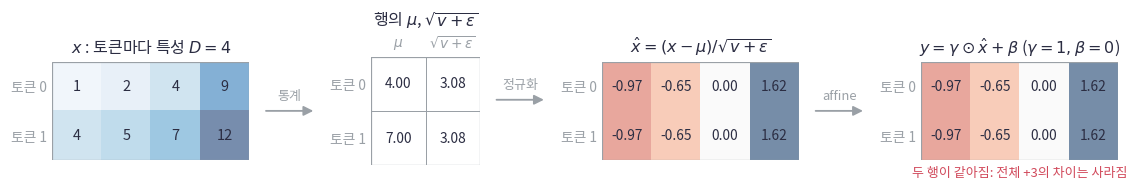

In [3]:
plot_layernorm(ln_demo, ln_mu.ravel(), ln_std.ravel(), ln_hat, ln_out)

🔍 **확인** · 행마다 평균 4와 7을 빼고 같은 표준편차로 나누니 두 행이 같아졌습니다. 전체 좌표에 같은 수를 더한 차이는 사라집니다. 따라서 LayerNorm은 정보를 무조건 보존하는 연산이 아닙니다. Transformer는 잔차 경로로 원래 입력을 함께 전달합니다.
아래 구현은 backward까지 포함하고, 검산은 $\gamma$가 1이 아니고 $\epsilon=0.07$인 경우로 합니다.

In [4]:
def layernorm_forward(X, gamma, beta, eps=1e-5):
    """LayerNorm forward: 마지막 축에서 x̂ = (x − μ)/√(v + ε), y = γ⊙x̂ + β. X: (N, T, D), gamma, beta: (D,) → (Y: (N, T, D), cache: (x̂, 1/√(v+ε), γ))."""
    centered = X - X.mean(axis=-1, keepdims=True)                                   # (N, T, D): x − μ
    inverse = 1 / np.sqrt(np.mean(centered ** 2, axis=-1, keepdims=True) + eps)     # (N, T, 1): r = (v + ε)^−½
    normalized = centered * inverse                                                 # (N, T, D): x̂
    return normalized * gamma + beta, (normalized, inverse, gamma)


def layernorm_backward(dY, cache):
    """LayerNorm backward: u = dY⊙γ, dX = r[u − mean(u) − x̂·mean(u⊙x̂)], dγ = Σ dY⊙x̂, dβ = Σ dY (배치·위치 합).
    dY: (N, T, D), cache: layernorm_forward의 것 → (dX: (N, T, D), dgamma: (D,), dbeta: (D,))."""
    normalized, inverse, gamma = cache
    u = dY * gamma                                                                  # (N, T, D): x̂의 기울기
    dX = inverse * (u - u.mean(axis=-1, keepdims=True)                              # 직접 경로 − 평균을 뺀 경로
                    - normalized * (u * normalized).mean(axis=-1, keepdims=True))   # − 분산을 거친 경로
    axes = tuple(range(dY.ndim - 1))                                                # 배치·위치 축 (0, 1)
    return dX, np.sum(dY * normalized, axis=axes), np.sum(dY, axis=axes)

In [5]:
def check_layernorm(candidate):
    """γ ≠ 1, ε = 0.07인 경우에 X·γ·β의 기울기를 중심차분과 대조합니다. → {"X", "gamma", "beta"}: 상대오차."""
    rng = np.random.default_rng(91)
    X = rng.normal(size=(2, 3, 4))                                  # (N, T, D)
    gamma, beta = rng.normal(size=4), rng.normal(size=4)
    Y, cache = layernorm_forward(X, gamma, beta, eps=0.07)
    G = rng.normal(size=Y.shape)                                    # 임의의 상류 기울기
    dx, dg, db = candidate(G, cache)

    def scalar():
        """검사기용: 스칼라 L = Σ Y ⊙ G."""
        return float(np.sum(layernorm_forward(X, gamma, beta, eps=0.07)[0] * G))

    errors = {name: rel_error(grad, numerical_gradient(scalar, value))
              for name, value, grad in [("X", X, dx), ("gamma", gamma, dg), ("beta", beta, db)]}
    assert all(np.isfinite(e) and e < 2e-6 for e in errors.values()), f"모든 상대오차가 2e−6 아래여야 합니다: {errors}"
    return errors

In [6]:
# 쓰는 것: ln_out (1절 손계산 셀)
ln_errors = check_layernorm(layernorm_backward)
print("LayerNorm 최대 상대오차:", max(ln_errors.values()))
ln_X = np.array([[[1., 2., 4., 9.], [4., 5., 7., 12.]]])          # (1, 2, 4): 손계산 두 토큰을 (N, T, D)로
ln_Y, _ = layernorm_forward(ln_X, np.ones(4), np.zeros(4))
np.testing.assert_allclose(ln_Y.mean(axis=-1), 0., atol=1e-12)    # 검산: 토큰마다 평균 0
np.testing.assert_allclose(ln_Y[:, 0], ln_Y[:, 1], atol=1e-12)     # 검산: 두 토큰이 같아짐
np.testing.assert_allclose(ln_Y[0], ln_out)                       # 검산: 위 손계산과 같은 값

LayerNorm 최대 상대오차: 3.266358006395601e-10


🔍 **확인** · $X$·$\gamma$·$\beta$ 미분이 중심차분과 $2\times10^{-6}$ 안에서 맞고, 손계산 두 행의 결과도 같습니다.

## 🔑 2. Multi-head attention: 축을 나누고 다시 모으기

**이 절에서 가져갈 것:** 폭 $D$를 head $A$개로 나눠 head마다 폭 $d_h=D/A$의 Q·K·V로 attention을 따로 계산하고, 결과의 열을 다시 합쳐 $W_o$로 섞습니다. 코드로는 `reshape(N,T,A,dh).transpose(0,2,1,3)`과 그 역입니다.

한 사람이 한 기준으로만 비교하는 대신, 특성 열을 두 묶음으로 나눠 두 사람이 서로 다른 기준으로 비교하게 하는 셈입니다. 각자가 $T\times T$ 가중치를 따로 만들고, 읽은 값을 옆으로 붙여 돌려줍니다.

> **용어**
>
> - **head**: 폭 $d_h$의 좌표 묶음 하나로 계산한 attention. head마다 다른 $Q, K, V$ 좌표를 보므로 서로 다른 가중치 $P$를 만듭니다.
> - **head 나누기·합치기(split·merge)**: `(N,T,D)`를 `(N,A,T,d_h)`로 바꾸는 reshape+transpose와 그 역. 값을 복사하지 않고 축만 다시 읽습니다.

모델 폭 D를 head 수 A로 나누어 $d_h=D/A$로 둡니다. A로 나누어떨어지는 D만 사용합니다. Q·K·V를 각각 `(N,T,D)`로 투영한 뒤
`(N,T,D) → reshape(N,T,A,dh) → transpose(N,A,T,dh)`로 바꿉니다.

각 head에서 독립적으로 $softmax(QK^T/\sqrt{d_h})V$를 계산합니다. 결과를 원래 축 순서로 합쳐 `(N,T,D)`로 만들고 $W_o$로 섞습니다. **각 head에 전체 D를 복사하는 구현이 아니라, 서로 다른 학습 좌표 묶음을 나누는 구현**입니다.

공유 mask는 `(T,T)`, 배치마다 다른 mask는 `(N,1,T,T)`로 줍니다. 가운데 1은 head 축에 공통으로 적용한다는 뜻입니다. `(N,T,T)`를 그대로 broadcast하면 N과 head 수가 같을 때 배치 축이 head 축에 잘못 맞아도 실행될 수 있어 이 구현에서는 거부합니다.

MHA backward는 출력 투영 → head 분리 → 각 head attention backward → head 합치기 → Q/K/V 입력 투영의 역순입니다. 입력 X는 세 투영으로 갈라졌으므로 $dX=dQW_q^T+dKW_k^T+dVW_v^T$로 더합니다.

아래는 토큰 3개, 폭 4를 head 2개로 나눈 손계산입니다. 투영은 난수 행렬이고 $W_o$는 항등으로 둡니다.

> **코드**
>
> - `mh_Q, mh_K, mh_V = [(mh_X @ mh_W[name]).reshape(3, 2, 2).transpose(1, 0, 2) for name in (…)]`: 투영 셋을 각각 (T, A, d_h)로 쪼갠 뒤 head 축을 앞으로 보내 세 이름에 풀어 받습니다.
> - `{**mh_W, "Wo": np.eye(4)}`: 사전 `mh_W`의 항목을 펼쳐 넣고 `Wo`를 더한 새 사전.
> - `np.stack([causal3, np.eye(3, dtype=bool)])`: mask 두 장을 쌓아 `(2, 3, 3)` = 배치마다 다른 mask. `[:, None]`으로 head 축을 끼우면 `(2, 1, 3, 3)`입니다.
> - `allowed.ndim not in (2, 4)`: 차원 수가 2도 4도 아니면 거부. `(N, T, T)` 3차원은 배치 축이 head 축에 잘못 맞을 수 있어 막습니다.
> - `weights[n, :, …]`에 mask의 부정(물결표 연산자)을 넣으면 n번째 예제의 모든 head에서 금지된 자리의 가중치만 고릅니다.

In [7]:
rng_mh = np.random.default_rng(920)
mh_X = rng_mh.normal(size=(3, 4))                                  # (T=3, D=4): 토큰 3개
mh_W = {name: rng_mh.normal(size=(4, 4)) * 0.5 for name in ("Wq", "Wk", "Wv")}   # 투영 셋 (D, D)
mh_Q, mh_K, mh_V = [(mh_X @ mh_W[name]).reshape(3, 2, 2).transpose(1, 0, 2) for name in ("Wq", "Wk", "Wv")]   # (A=2, T, d_h=2): head 축을 앞으로
mh_S = mh_Q @ mh_K.swapaxes(-1, -2) / np.sqrt(2)                   # (2, 3, 3): head 마다 점수 (√d_h = √2)
mh_P = np.exp(mh_S - mh_S.max(axis=-1, keepdims=True))
mh_P /= mh_P.sum(axis=-1, keepdims=True)                           # (2, 3, 3): head 마다 가중치
mh_O = (mh_P @ mh_V).transpose(1, 0, 2).reshape(3, 4)              # (T, D): head 출력을 열로 합침
print("head 0의 P\n", mh_P[0], "\nhead 1의 P\n", mh_P[1])

head 0의 P
 [[0.3231 0.3323 0.3446]
 [0.25   0.3527 0.3973]
 [0.2795 0.3531 0.3674]] 
head 1의 P
 [[0.0964 0.6039 0.2997]
 [0.2927 0.2832 0.424 ]
 [0.2296 0.3863 0.3841]]


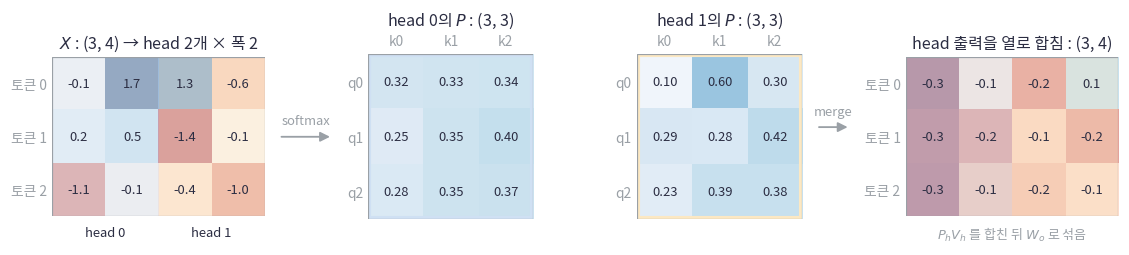

In [8]:
plot_head_split(mh_X, mh_P, mh_O)

🔍 **확인** · 왼쪽 $X$의 앞 두 열(파랑)이 head 0, 뒤 두 열(금색)이 head 1의 좌표입니다. 두 head의 가중치 $P$가 서로 다릅니다. 보는 좌표가 다르기 때문입니다.
head마다 읽은 값을 열로 붙이면 다시 폭 4가 되고, 그다음 $W_o$가 두 head의 결과를 섞습니다. 아래 구현은 split·merge, 08번의 attention, MHA forward·backward입니다.

In [9]:
def split_heads(X, heads):
    """(N, T, D) → (N, heads, T, D/heads). 폭을 head 묶음으로 쪼개고 head 축을 앞으로. 값 복사 없이 축만 다시 읽습니다."""
    N, T, D = X.shape
    assert D % heads == 0, "폭 D는 head 수로 나누어떨어져야 합니다"
    return X.reshape(N, T, heads, D // heads).transpose(0, 2, 1, 3)


def merge_heads(X):
    """(N, heads, T, d_h) → (N, T, heads·d_h). split_heads의 역."""
    N, heads, T, width = X.shape
    return X.transpose(0, 2, 1, 3).reshape(N, T, heads * width)

In [10]:
def attention_forward(Q, K, V, allowed=None):
    """08번의 attention을 head 축이 있는 4차원 (N, A, T, d_h)에 그대로. mask는 (T, T) 또는 (N, 1, T, T)만 받습니다.
    → (O: (N, A, T_q, d_v), cache: (Q, K, V, P, mask, scale))."""
    scale = np.sqrt(Q.shape[-1])                            # √d_h
    S = Q @ K.swapaxes(-1, -2) / scale                      # (N, A, T_q, T_k): 마지막 두 축만 곱함
    if allowed is None:
        mask = np.ones(S.shape, dtype=bool)
    else:
        allowed = np.asarray(allowed, dtype=bool)
        if allowed.ndim not in (2, 4):
            raise ValueError("MHA mask는 (T,T) 또는 (N,1,T,T)처럼 head 축을 명시해야 합니다")
        mask = np.broadcast_to(allowed, S.shape)
    if not np.all(mask.any(axis=-1)):
        raise ValueError("각 query에 허용된 key가 하나 이상 필요합니다")
    S = np.where(mask, S, -np.inf)                          # 금지 자리는 −∞
    exps = np.exp(S - S.max(axis=-1, keepdims=True))
    P = exps / exps.sum(axis=-1, keepdims=True)             # key 축에서 합 1
    return P @ V, (Q, K, V, P, mask, scale)

In [11]:
def attention_backward(dO, cache):
    """08번 3절의 backward를 4차원에 그대로: dP = dO Vᵀ, dS = P⊙(dP − Σ dP⊙P) (금지 자리 0), dQ = dS K/√d_h, dK = dSᵀ Q/√d_h, dV = Pᵀ dO."""
    Q, K, V, P, mask, scale = cache
    dP = dO @ V.swapaxes(-1, -2)                            # O = PV 의 P 쪽
    dS = P * (dP - (dP * P).sum(axis=-1, keepdims=True))    # softmax backward 한 줄
    dS = np.where(mask, dS, 0.)                             # 금지 자리는 손실에 영향 없음
    return dS @ K / scale, dS.swapaxes(-1, -2) @ Q / scale, P.swapaxes(-1, -2) @ dO   # dQ, dK, dV

In [12]:
def mha_forward(X, p, heads=2, allowed=None):
    """Multi-head attention forward: 투영 셋 → head 나누기 → head마다 attention → 합치기 → W_o.
    X: (N, T, D), p: {"Wq", "Wk", "Wv", "Wo"} 각 (D, D) → (Y: (N, T, D), cache: (X, 합친 O, attention 캐시, heads))."""
    # 쓰는 것: split_heads, merge_heads (2절)
    Q, K, V = [split_heads(X @ p[k], heads) for k in ["Wq", "Wk", "Wv"]]   # (N, A, T, d_h) 셋
    O, attention_cache = attention_forward(Q, K, V, allowed)
    joined = merge_heads(O)                                 # (N, T, D): head 출력을 열로 붙임
    return joined @ p["Wo"], (X, joined, attention_cache, heads)

In [13]:
def mha_backward(dY, cache, p):
    """MHA backward: W_o → head 나누기 → attention backward → head 합치기 → 세 투영. X는 세 갈래로 갈라졌으므로 dX = dQW_qᵀ + dKW_kᵀ + dVW_vᵀ.
    dY: (N, T, D), cache: mha_forward의 것 → (dX: (N, T, D), grads: {"Wq", "Wk", "Wv", "Wo"})."""
    # 쓰는 것: split_heads, merge_heads (2절)
    X, joined, attention_cache, heads = cache
    D = X.shape[-1]
    grads = {"Wo": joined.reshape(-1, D).T @ dY.reshape(-1, D)}   # (D, D): 배치·위치를 함께 합한 dW_o
    dO = split_heads(dY @ p["Wo"].T, heads)                 # (N, A, T, d_h): W_o를 거꾸로 지나 head로 나눔
    dQ, dK, dV = [merge_heads(g) for g in attention_backward(dO, attention_cache)]   # (N, T, D) 셋
    dX = np.zeros_like(X)
    for name, grad in zip(["Wq", "Wk", "Wv"], [dQ, dK, dV]):   # 투영마다
        grads[name] = X.reshape(-1, D).T @ grad.reshape(-1, D)   # dW = Xᵀ dQ (배치·위치 합)
        dX += grad @ p[name].T                              # 세 갈래의 입력 기울기를 더함
    return dX, grads

In [14]:
# 쓰는 것: split_heads, merge_heads, mha_forward, mha_backward (2절)
rng = np.random.default_rng(92)                             # 이 노트북의 검산용 난수 생성기. 3절도 이어 씁니다
head_X = rng.normal(size=(2, 3, 4))                         # (N, T, D)
np.testing.assert_array_equal(merge_heads(split_heads(head_X, 2)), head_X)   # 검산: 나눴다 합치면 원래대로
head_p = {k: rng.normal(size=(4, 4)) * 0.3 for k in ["Wq", "Wk", "Wv", "Wo"]}
causal3 = np.arange(3)[None, :] <= np.arange(3)[:, None]    # (3, 3): causal mask (08번 4절)
head_Y, head_cache = mha_forward(head_X, head_p, 2, causal3)
head_G = rng.normal(size=head_Y.shape)                      # 임의의 상류 기울기
head_dx, head_grads = mha_backward(head_G, head_cache, head_p)


def mha_scalar():
    """검사기용: 스칼라 L = Σ Y ⊙ G."""
    return float(np.sum(mha_forward(head_X, head_p, 2, causal3)[0] * head_G))


mha_errors = {k: rel_error(head_grads[k], numerical_gradient(mha_scalar, v)) for k, v in head_p.items()}   # 투영마다
mha_errors["X"] = rel_error(head_dx, numerical_gradient(mha_scalar, head_X))
assert max(mha_errors.values()) < 2e-6, "입력과 네 투영의 상대오차가 모두 2e−6 아래여야 합니다"
print("MHA의 입력·네 투영 미분 최대 상대오차:", max(mha_errors.values()))

MHA의 입력·네 투영 미분 최대 상대오차: 1.3941559756060622e-09


In [15]:
# 쓰는 것: mh_X, mh_W, mh_O, mh_P (2절 손계산 셀) · head_X, head_p, causal3 (앞 검산 셀)
per_example_mask = np.stack([causal3, np.eye(3, dtype=bool)])   # (2, 3, 3): 예제마다 다른 mask
try:
    mha_forward(head_X, head_p, 2, per_example_mask)            # (N, T, T)는 거부해야 함
except ValueError as error:
    print("예상한 mask shape 거부:", error)
else:
    raise AssertionError("배치·head 축 혼동을 놓쳤습니다")
_, per_example_cache = mha_forward(head_X, head_p, 2, per_example_mask[:, None])   # (N, 1, T, T)로 head 축을 명시
weights = per_example_cache[2][3]                               # (N, A, T, T): attention 캐시의 P
for n in range(2):
    assert np.all(weights[n, :, ~per_example_mask[n]] == 0), "금지된 자리의 가중치는 모든 head에서 0이어야 합니다"
print("배치마다 다른 mask를 모든 head에 적용하는 검산 통과")
mh_out, mh_cache = mha_forward(mh_X[None], {**mh_W, "Wo": np.eye(4)}, 2)   # 손계산 설정: W_o = 항등
np.testing.assert_allclose(mh_out[0], mh_O)                     # 검산: 위 손계산의 합친 출력과 같음
np.testing.assert_allclose(mh_cache[2][3][0], mh_P)             # 검산: 두 head의 가중치도 같음

예상한 mask shape 거부: MHA mask는 (T,T) 또는 (N,1,T,T)처럼 head 축을 명시해야 합니다
배치마다 다른 mask를 모든 head에 적용하는 검산 통과


🔍 **확인** · 입력과 네 투영의 미분이 모두 중심차분과 맞습니다. `(N,T,T)` mask는 거부하고, `(N,1,T,T)` mask는 배치마다 다른 금지 위치를 모든 head에 적용합니다. 손계산의 두 head 가중치도 같은 함수가 냅니다.

## 🔑 3. 잔차와 위치별 FFN의 전체 블록

**이 절에서 가져갈 것:** 블록은 $U=X+\mathrm{MHA}(\mathrm{LN}_1(X))$, $Y=U+\mathrm{FFN}(\mathrm{LN}_2(U))$입니다. 잔차의 backward는 상류 기울기를 **그대로 더하는** 항등 항이 있고, FFN은 위치마다 같은 MLP라 위치 사이를 읽지 않습니다.

> **용어**
>
> - **잔차 연결(residual connection)**: 하위 층의 출력에 그 입력을 그대로 더하는 것. 하위 층이 0을 내면 블록은 항등이 되고, 기울기도 항등 경로로 그대로 지나갑니다.
> - **위치별 FFN(position-wise feed-forward)**: 토큰마다 같은 $W_1, W_2$의 2층 MLP. 03번의 MLP를 $(N\cdot T)$개 행에 한꺼번에 적용한 것입니다.

이 노트북의 블록은 다음 식입니다.
$$A=LN_1(X),\quad U=X+MHA(A),$$
$$B=LN_2(U),\quad F=ReLU(BW_1+b_1)W_2+b_2,\quad Y=U+F.$$

FFN은 각 위치에 **같은 MLP**를 적용하며 그 자체로 다른 위치를 읽지 않습니다. 위치 간 정보 교환은 MHA에서 일어납니다. $W_1:(D,D_{ff}),W_2:(D_{ff},D)$입니다.

잔차 $Y=U+F(U)$의 backward는 $dU=dY+(\partial F/\partial U)^TdY$입니다. 첫 항은 항등 경로입니다. 아래 코드의 `dU = dY + dU_norm`에서 dY가 마지막 잔차의 직접 기여입니다. `return dU + dX_norm`에서는 dU가 첫 잔차의 직접 기여이며, 각 하위 층을 거친 미분을 더합니다.

ReLU는 0에서 미분이 유일하지 않아 코드에서는 0을 선택합니다. 수치미분 검사는 꺾임을 가로지르지 않는 작은 임의 입력에서 수행합니다.

아래 도식이 이 블록입니다. 금색 화살표가 두 잔차의 항등 경로입니다.

> **코드**
>
> - `A.reshape(-1, A.shape[-1]).T @ dY.reshape(-1, D)`: 배치·위치 두 축을 하나로 펼친 뒤 행렬곱. 위치별 affine의 dW를 모든 토큰에서 합한 것입니다(08번 5절). `dY.sum(axis=(0, 1))`은 같은 두 축의 합이라 db입니다.
> - `dU_norm, grads["gamma2"], grads["beta2"] = layernorm_backward(dB, ln2)`: 돌려준 세 값을 변수 하나와 사전 항목 둘에 바로 풀어 넣습니다.
> - `grads.update(mha_grads)`: 다른 사전의 항목을 이 사전에 합칩니다.
> - `identity_p["Wo"][:] = 0`: 배열을 새로 만들지 않고 모든 원소를 제자리에서 0으로.

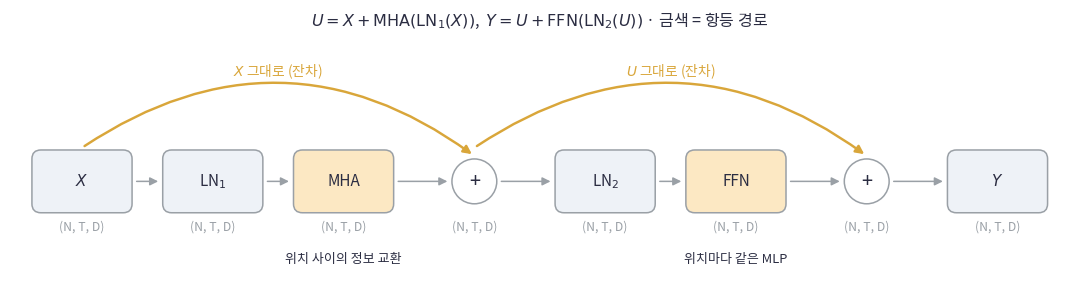

In [16]:
plot_transformer_block()

🔍 **확인** · 텐서 모양은 블록 안에서 $(N,T,D)$로 유지되므로 같은 블록을 몇 개든 이어 쌓을 수 있습니다. MHA 상자만 위치 사이를 읽고, FFN은 위치마다 따로 계산합니다.
금색 경로 덕분에 MHA와 FFN의 출력이 0이면 $Y=X$이고 $dX=dY$입니다. 아래 검산에서 $W_o, W_2, b_2$를 0으로 두어 이 항등을 직접 확인합니다.

In [17]:
def ffn_forward(X, p):
    """위치별 FFN forward: F = ReLU(XW₁ + b₁)W₂ + b₂. 토큰마다 같은 2층 MLP. X: (N, T, D) → (F: (N, T, D), cache: (X, Z, A))."""
    Z = X @ p["W1"] + p["b1"]                               # (N, T, D_ff): 활성 전 값
    A = np.maximum(Z, 0)                                    # ReLU
    return A @ p["W2"] + p["b2"], (X, Z, A)


def ffn_backward(dY, cache, p):
    """위치별 FFN backward (03번 5절의 두 층). dY: (N, T, D) → (dX: (N, T, D), grads: {"W1", "b1", "W2", "b2"})."""
    X, Z, A = cache
    dZ = (dY @ p["W2"].T) * (Z > 0)                         # (N, T, D_ff): 둘째 층을 거꾸로, ReLU 도함수를 곱함
    grads = {"W2": A.reshape(-1, A.shape[-1]).T @ dY.reshape(-1, dY.shape[-1]),   # dW₂ = Aᵀ dY (배치·위치 합)
             "b2": dY.sum(axis=(0, 1)),
             "W1": X.reshape(-1, X.shape[-1]).T @ dZ.reshape(-1, dZ.shape[-1]),   # dW₁ = Xᵀ dZ
             "b1": dZ.sum(axis=(0, 1))}
    return dZ @ p["W1"].T, grads

In [18]:
def block_forward(X, p, heads=2, allowed=None):
    """Pre-LN 블록 forward: A = LN₁(X), U = X + MHA(A), B = LN₂(U), Y = U + FFN(B). X: (N, T, D) → (Y: (N, T, D), cache: (ln1, mha, ln2, ffn) 캐시 넷)."""
    # 쓰는 것: layernorm_forward (1절) · mha_forward (2절)
    A, ln1 = layernorm_forward(X, p["gamma1"], p["beta1"])
    M, mha = mha_forward(A, p, heads, allowed)
    U = X + M                                               # 첫 잔차
    B, ln2 = layernorm_forward(U, p["gamma2"], p["beta2"])
    F, ffn = ffn_forward(B, p)
    return U + F, (ln1, mha, ln2, ffn)                      # 둘째 잔차

In [19]:
def block_backward(dY, cache, p):
    """블록 backward: FFN → LN₂ → (잔차: dU = dY + dU_norm) → MHA → LN₁ → (잔차: dX = dU + dX_norm).
    dY: (N, T, D), cache: block_forward의 것 → (dX: (N, T, D), grads: 블록의 모든 파라미터)."""
    # 쓰는 것: layernorm_backward (1절) · mha_backward (2절)
    ln1, mha, ln2, ffn = cache
    dB, grads = ffn_backward(dY, ffn, p)
    dU_norm, grads["gamma2"], grads["beta2"] = layernorm_backward(dB, ln2)
    dU = dY + dU_norm                                       # 둘째 잔차: 항등 경로 dY + FFN 경로
    dA, mha_grads = mha_backward(dU, mha, p)
    grads.update(mha_grads)
    dX_norm, grads["gamma1"], grads["beta1"] = layernorm_backward(dA, ln1)
    return dU + dX_norm, grads                              # 첫 잔차: 항등 경로 dU + MHA 경로

In [20]:
def init_block(D=12, hidden=24, seed=93):
    """블록 파라미터 사전: 투영 넷 (D, D), LN의 γ·β 둘씩, FFN의 W₁ (D, hidden)·W₂ (hidden, D)와 편향."""
    rng = np.random.default_rng(seed)
    p = {k: rng.normal(size=(D, D)) / np.sqrt(D) for k in ["Wq", "Wk", "Wv", "Wo"]}
    p.update({"gamma1": np.ones(D), "beta1": np.zeros(D), "gamma2": np.ones(D), "beta2": np.zeros(D),
              "W1": rng.normal(size=(D, hidden)) * np.sqrt(2 / D), "b1": np.zeros(hidden),   # ReLU 층은 He 초기화
              "W2": rng.normal(size=(hidden, D)) / np.sqrt(hidden), "b2": np.zeros(D)})
    return p

In [21]:
def check_block_backward(candidate):
    """D = 4, hidden = 6인 작은 블록에서 모든 파라미터와 입력의 기울기를 중심차분과 대조합니다. → 상대오차 사전."""
    # 쓰는 것: block_forward, init_block (3절)
    X = np.random.default_rng(94).normal(size=(2, 3, 4))    # (N, T, D)
    p = init_block(4, 6, 95)
    Y, cache = block_forward(X, p)
    G = np.random.default_rng(96).normal(size=Y.shape)      # 임의의 상류 기울기
    dX, grads = candidate(G, cache, p)

    def scalar():
        """검사기용: 스칼라 L = Σ Y ⊙ G."""
        return float(np.sum(block_forward(X, p)[0] * G))

    errors = {k: rel_error(grads[k], numerical_gradient(scalar, v)) for k, v in p.items()}
    errors["X"] = rel_error(dX, numerical_gradient(scalar, X))
    assert all(np.isfinite(e) and e < 2e-6 for e in errors.values()), f"모든 상대오차가 2e−6 아래여야 합니다: {errors}"
    return errors

In [22]:
# 쓰는 것: rng (2절 MHA 검산 셀) · block_forward, block_backward, init_block (3절)
block_errors = check_block_backward(block_backward)
print("Transformer 블록 전체 미분 최대 상대오차:", max(block_errors.values()))
# 잔차를 직접 확인: MHA 출력과 FFN 출력을 모두 0으로 만들면 블록은 항등입니다.
identity_p = init_block(4, 6)
identity_p["Wo"][:] = 0                                     # MHA 출력 0
identity_p["W2"][:] = 0                                     # FFN 출력 0
identity_p["b2"][:] = 0
identity_X = rng.normal(size=(2, 3, 4))
identity_Y, identity_cache = block_forward(identity_X, identity_p)
identity_G = rng.normal(size=identity_Y.shape)
identity_dX, _ = block_backward(identity_G, identity_cache, identity_p)
np.testing.assert_allclose(identity_Y, identity_X)          # 검산: forward가 항등 Y = X
np.testing.assert_allclose(identity_dX, identity_G)         # 검산: backward도 항등 dX = dY
print("두 잔차의 항등 forward·backward 검산 통과")

Transformer 블록 전체 미분 최대 상대오차: 6.892493636954047e-10
두 잔차의 항등 forward·backward 검산 통과


🔍 **확인** · 블록의 모든 파라미터와 입력의 미분이 중심차분과 맞고, 하위 층 출력을 0으로 만든 블록은 forward·backward 모두 항등입니다.

## 🔑 4. 위치와 embedding: 정수 인덱스를 실수 벡터로

**이 절에서 가져갈 것:** 정수 토큰은 embedding 표 $E$의 행을 고르는 번호일 뿐이라 미분하지 않습니다. 고른 행으로 기울기를 누적하고(`np.add.at`), 위치 표를 더해야 같은 토큰이 다른 위치에서 다른 벡터가 되어 순서를 읽을 수 있습니다.

> **용어**
>
> - **토큰(token)·embedding 표** $E:(V,D)$: 기호 $V$종마다 길이 $D$의 벡터를 한 행씩 둔 표. `E[tokens]`는 `(N,T,D)`이고 one-hot과 $E$의 행렬곱과 같습니다.
> - **위치 표** $P:(T_{max},D)$: 위치 $t$마다 더하는 벡터. 학습 가능한 표를 쓰거나 고정 sinusoidal 값을 씁니다. 여기서는 둘 중 하나만 더합니다.

정수 토큰 `tokens:(N,T)`는 embedding 표 $E:(V,D)$의 행을 고릅니다. `E[tokens]`의 결과는 `(N,T,D)`입니다. 이는 one-hot과 E를 행렬곱한 것과 같습니다. **정수 인덱스는 미분하지 않고, 선택된 E의 행으로 미분을 누적**합니다.

같은 토큰이 여러 번 나올 수 있어 `dE[tokens] += dX`라는 고급 인덱싱은 반복 인덱스의 누적을 놓칠 수 있습니다. `np.add.at(dE,tokens,dX)`는 각 등장 위치를 모두 더합니다. 아래 전체 검사는 반복 토큰을 포함합니다.

위치가 없고 mask도 없으면 self-attention·LayerNorm·위치별 FFN의 조합은 입력의 순열에 따라 출력도 같은 순열로 바뀝니다. 그래서 절대 위치별 뒤집기를 학습하려면 위치 정보가 필요합니다.

원 논문의 고정 sinusoidal 위치는
$$PE(t,2i)=\sin(t/10000^{2i/D}),\quad PE(t,2i+1)=\cos(t/10000^{2i/D})$$
입니다. 짝수 좌표는 sin, 홀수 좌표는 cos이고 좌표 번호가 클수록 느리게 진동합니다. **완성 학습 실험은 별도의 학습 가능한 위치 표 P를 사용**합니다. $X=E[tokens]+P[:T]$이며, P의 미분은 해당 위치의 배치 합입니다. 둘은 위치를 넣는 대안이며 이번 모델에 두 표를 함께 더하지 않습니다.

아래는 토큰 `[0, 3, 1, 2]`가 난수 표 $E$의 행을 고르고 위치 표를 더하는 모습과, 고정 sinusoidal 표입니다.

> **코드**
>
> - `10000 ** (even / D)`: 좌표 번호 2i마다 다른 파장. `positions / …`은 `(T, 1) / (1, D/2)` 브로드캐스팅으로 (위치, 진동수) 표를 만듭니다.
> - `result[:, 0::2], result[:, 1::2] = np.sin(angles), np.cos(angles)`: 짝수 열과 홀수 열 슬라이스에 sin·cos를 동시에 넣습니다.
> - `p.update({…})`: 블록 파라미터 사전에 E·P·출력층을 덧붙입니다.
> - `np.add.at(grads["E"], tokens, dX)`: tokens가 가리키는 행마다 dX를 누적. 같은 토큰이 여러 번 나와도 모두 더합니다.
> - `tokens[:, ::-1]`: 각 행을 뒤집은 토큰열. `logits.reshape(-1, V)`: (N, T, V)를 NT개 행으로 펼쳐 02번의 CE를 그대로 씁니다.

In [23]:
rng_emb = np.random.default_rng(970)
emb_tokens = np.array([0, 3, 1, 2])                                # (T=4,): 정수 토큰
emb_E = rng_emb.normal(size=(4, 12)) * 0.2                         # (V=4, D=12): embedding 표
emb_P = rng_emb.normal(size=(4, 12)) * 0.2                         # (T_max=4, D): 학습 가능한 위치 표
emb_rows = emb_E[emb_tokens]                                       # (T, D): 토큰이 고른 행
np.testing.assert_allclose(np.eye(4)[emb_tokens] @ emb_E, emb_rows)   # 검산: one-hot @ E 와 같음
emb_X = emb_rows + emb_P[:4]                                       # (T, D): 블록의 입력
sin_pos, sin_even = np.arange(12)[:, None], np.arange(0, 12, 2)[None, :]   # (12, 1) 위치, (1, 6) 짝수 좌표 번호
sin_angles = sin_pos / (10000 ** (sin_even / 12))                  # (12 위치, 6 진동수): 각도
sin_grid = np.empty((12, 12))
sin_grid[:, 0::2], sin_grid[:, 1::2] = np.sin(sin_angles), np.cos(sin_angles)   # 짝수 열 sin, 홀수 열 cos
print("E[tokens]", emb_rows.shape, "· X", emb_X.shape, "· 고정 위치 표", sin_grid.shape)

E[tokens] (4, 12) · X (4, 12) · 고정 위치 표 (12, 12)


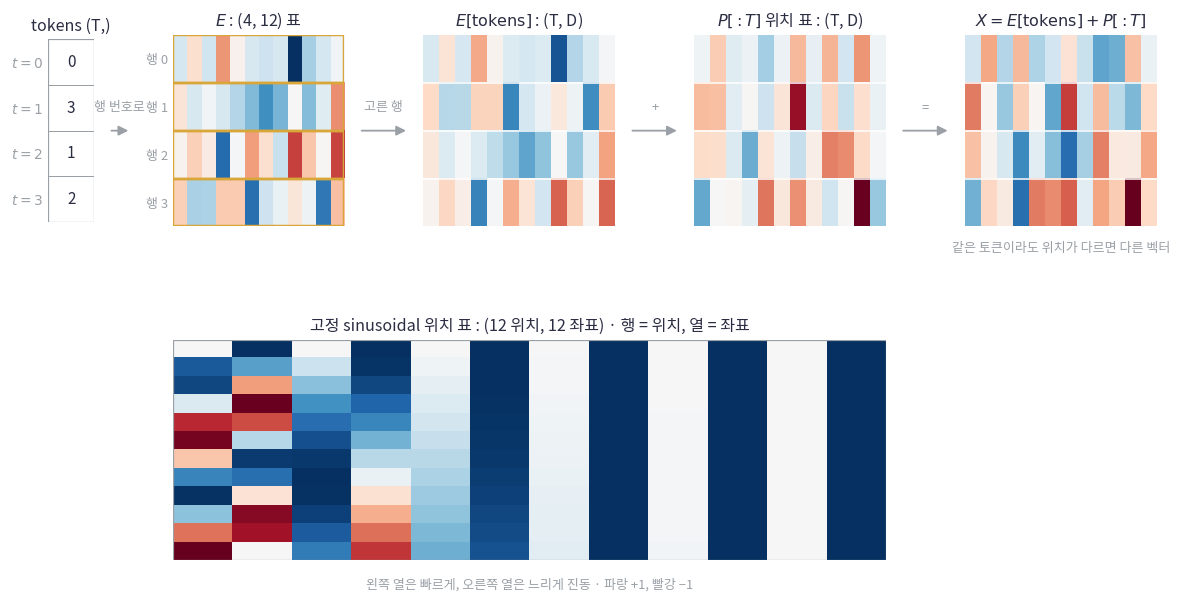

In [24]:
plot_embedding_positions(emb_tokens, emb_E, emb_rows, emb_P[:4], emb_X, sin_grid)

🔍 **확인** · 위 행에서 토큰 번호가 $E$의 행(금색)을 고르고, 위치 표를 더하면 블록 입력 $X$가 됩니다. 토큰 값이 같아도 위치가 다르면 다른 벡터입니다.
아래 sinusoidal 표는 왼쪽 열이 빠르게, 오른쪽 열이 느리게 진동합니다. 여러 진동수의 조합으로 위치마다 다른 무늬가 생깁니다. 아래 구현은 이 표와 embedding·위치·출력층을 포함한 전체 모델과 그 backward입니다.

In [25]:
def sinusoidal_positions(T, D):
    """고정 sinusoidal 위치 표: PE(t, 2i) = sin(t/10000^(2i/D)), PE(t, 2i+1) = cos(·). T: 길이, D: 짝수 폭 → (T, D)."""
    assert D % 2 == 0, "sin·cos 쌍을 두려면 폭 D가 짝수여야 합니다"
    positions = np.arange(T)[:, None]                       # (T, 1)
    even = np.arange(0, D, 2)[None, :]                      # (1, D/2): 짝수 좌표 번호
    angles = positions / (10000 ** (even / D))              # (T, D/2)
    result = np.empty((T, D))
    result[:, 0::2], result[:, 1::2] = np.sin(angles), np.cos(angles)
    return result

In [26]:
def init_transformer(vocab=4, length=4, D=12, hidden=24, seed=97):
    """전체 모델 파라미터: 블록(init_block) + embedding 표 E (vocab, D) + 위치 표 P (length, D) + 출력층 Wout (D, vocab)·bout."""
    # 쓰는 것: init_block (3절)
    p = init_block(D, hidden, seed)
    rng = np.random.default_rng(seed + 1)
    p.update({"E": rng.normal(size=(vocab, D)) * 0.2, "P": rng.normal(size=(length, D)) * 0.2,
              "Wout": rng.normal(size=(D, vocab)) / np.sqrt(D), "bout": np.zeros(vocab)})
    return p

In [27]:
def transformer_forward(tokens, p, heads=2, allowed=None, use_positions=True):
    """전체 forward: X = E[tokens] (+ P[:T]) → 블록 → logits = Y Wout + bout. tokens: (N, T) 정수 → (logits: (N, T, V), cache)."""
    # 쓰는 것: block_forward (3절)
    N, T = tokens.shape
    X = p["E"][tokens]                                      # (N, T, D): 토큰이 고른 행
    if use_positions:
        assert T <= len(p["P"]), "학습 위치 표 길이를 넘었습니다"
        X = X + p["P"][:T]                                  # 위치 표를 더함 (T, D)가 배치에 브로드캐스팅
    Y, cache = block_forward(X, p, heads, allowed)
    logits = Y @ p["Wout"] + p["bout"]                      # (N, T, V): 위치마다 기호 점수
    return logits, (tokens, Y, cache, use_positions)

In [28]:
def transformer_backward(dlogits, cache, p, block_backward_fn=block_backward):
    """전체 backward: 출력층 → 블록 → E(고른 행에 누적)·P(위치별 배치 합). dlogits: (N, T, V) → grads: p와 같은 키."""
    # 쓰는 것: block_backward (3절)
    tokens, Y, block_cache, use_positions = cache
    D = Y.shape[-1]
    dX, grads = block_backward_fn(dlogits @ p["Wout"].T, block_cache, p)   # 출력층을 거꾸로 지나 블록 backward
    grads["Wout"] = Y.reshape(-1, D).T @ dlogits.reshape(-1, dlogits.shape[-1])   # (D, V): 배치·위치 합
    grads["bout"] = dlogits.sum(axis=(0, 1))
    grads["E"] = np.zeros_like(p["E"])
    np.add.at(grads["E"], tokens, dX)                       # 토큰이 고른 행마다 누적 (반복 토큰도 전부)
    grads["P"] = np.zeros_like(p["P"])
    if use_positions:
        grads["P"][:tokens.shape[1]] = dX.sum(axis=0)       # (T, D): 위치마다 배치 합
    return grads

In [29]:
def token_ce(logits, targets):
    """모든 위치의 softmax CE 평균과 기울기 (02번 8절을 NT개 행에). logits: (N, T, V), targets: (N, T) 정수 → (J, dlogits: (N, T, V) = (P − T)/NT)."""
    N, T, V = logits.shape
    z, y = logits.reshape(-1, V), targets.reshape(-1)       # (NT, V), (NT,): 위치를 행으로 펼침
    shifted = z - z.max(axis=-1, keepdims=True)
    logp = shifted - np.log(np.exp(shifted).sum(axis=-1, keepdims=True))   # log softmax
    grad = np.exp(logp)                                     # P
    grad[np.arange(N * T), y] -= 1                          # 정답 자리만 1을 빼면 P − T
    return -logp[np.arange(N * T), y].mean(), (grad / (N * T)).reshape(N, T, V)

In [30]:
def check_transformer(block_backward_fn=block_backward):
    """반복 토큰이 든 작은 모델(V = 3, D = 4)에서 모든 파라미터의 기울기를 중심차분과 대조합니다. → 상대오차 사전."""
    # 쓰는 것: init_transformer, transformer_forward, transformer_backward, token_ce (4절) · block_backward (3절, 기본 인자)
    tokens = np.array([[0, 1, 0], [2, 1, 1]])               # (N, T): 반복 토큰 포함
    targets = tokens[:, ::-1]                               # 뒤집은 열
    p = init_transformer(3, 3, 4, 6, 98)
    logits, cache = transformer_forward(tokens, p)
    _, dlogits = token_ce(logits, targets)
    grads = transformer_backward(dlogits, cache, p, block_backward_fn)

    def scalar():
        """검사기용: 손실값 하나."""
        return float(token_ce(transformer_forward(tokens, p)[0], targets)[0])

    errors = {k: rel_error(grads[k], numerical_gradient(scalar, v)) for k, v in p.items()}
    assert all(np.isfinite(e) and e < 2e-6 for e in errors.values()), f"모든 상대오차가 2e−6 아래여야 합니다: {errors}"
    return errors

In [31]:
# 쓰는 것: sinusoidal_positions, check_transformer (4절) · sin_grid (4절 그림 셀)
position_grid = sinusoidal_positions(12, 12)
np.testing.assert_allclose(position_grid[0, 0::2], 0.)       # 검산: 위치 0의 sin 좌표는 0
np.testing.assert_allclose(position_grid[0, 1::2], 1.)       # 검산: cos 좌표는 1
transformer_errors = check_transformer()
print("embedding·위치·head까지 모든 파라미터 최대 상대오차:", max(transformer_errors.values()))
np.testing.assert_allclose(sinusoidal_positions(12, 12), sin_grid)    # 검산: 위 그림의 표와 같음

embedding·위치·head까지 모든 파라미터 최대 상대오차: 1.4834569676899003e-09


🔍 **확인** · 반복 토큰 `[0, 1, 0]`, `[2, 1, 1]`을 포함한 전체 모델에서 $E$·$P$·블록·출력층의 모든 파라미터 미분이 중심차분과 맞습니다. 고정 위치 표도 손계산과 같습니다.

## 🔑 5. 완성 학습: 네 토큰을 역순으로 바꾸기

**이 절에서 가져갈 것:** 입력 네 토큰을 모두 본 뒤 출력 네 토큰을 동시에 분류합니다. 목적은 $NT$개 위치의 평균 CE이고, 위치 $t$의 출력은 위치 $T-1-t$의 입력을 읽어야 하므로 위치 정보와 양방향 attention이 필요합니다.

> **용어**
>
> - **양방향 attention**: mask 없이 모든 위치가 서로를 읽는 것. causal mask를 씌우면 첫 출력이 마지막 입력을 읽을 수 없습니다.
> - **토큰 정확도·문장 정확도**: 위치별로 맞힌 비율과, 네 위치를 모두 맞힌 문장의 비율. 둘을 함께 봅니다.

예를 들어 `[0,3,1,2] → [2,1,3,0]`입니다. 입력 네 토큰 전체를 보고 출력 네 토큰을 동시에 분류합니다. **양방향 attention**을 사용하므로 미래 위치도 읽을 수 있습니다. 여기서 causal mask를 씌우면 첫 출력이 마지막 입력을 읽을 수 없어 문제의 정보 조건이 달라집니다.

4종 기호의 길이 4 조합 $4^4=256$개를 생성하고, 192개는 학습·64개는 검증으로 분리합니다. 같은 토큰열이 양쪽에 들어가지 않습니다. 학습은 800스텝, 배치 64, Adam 학습률 0.01입니다. 목적은 $NT$개 위치의 평균 CE이며, 지표는 **토큰별 정확도**와 **네 위치 모두 맞힌 문장 정확도**를 함께 봅니다.

📎 가변 길이 padding은 이 실험에 없습니다. padding을 추가하면 key mask와 함께 유효 target 위치만 손실에 포함하고 그 개수로 평균내야 합니다. 마지막 코드의 `/ (N*T)`를 그대로 쓰면 평균의 의미가 달라집니다.

> **코드**
>
> - `product(range(4), repeat=4)`: 0–3에서 네 개를 뽑는 모든 조합 256개(itertools). `np.array(list(…))`로 `(256, 4)`.
> - `set(map(tuple, a)).isdisjoint(set(map(tuple, b)))`: 행을 튜플로 바꿔 집합으로 만들고, 두 집합에 공통 원소가 없는지.
> - `rng_train.choice(192, 64, replace=False)`: 겹치지 않는 번호 64개 = 미니배치.
> - `np.all(predictions == valid_targets, axis=1)`: 문장마다 네 위치가 모두 맞았는지.
> - `trained_cache[2][1][2][3][0]`: 캐시 안의 캐시. 전체 캐시의 블록 캐시(2) → MHA 캐시(1) → attention 캐시(2) → P(3) → 배치 0. 학습된 attention 가중치 `(A, T, T)`입니다.

In [32]:
rev_inputs = np.array([[0, 3, 1, 2], [1, 1, 2, 0], [3, 0, 0, 2]])   # (3, 4): 예 세 개
rev_targets = rev_inputs[:, ::-1]                                  # (3, 4): 정답 = 뒤집은 열
print("입력\n", rev_inputs, "\n정답\n", rev_targets)

입력
 [[0 3 1 2]
 [1 1 2 0]
 [3 0 0 2]] 
정답
 [[2 1 3 0]
 [0 2 1 1]
 [2 0 0 3]]


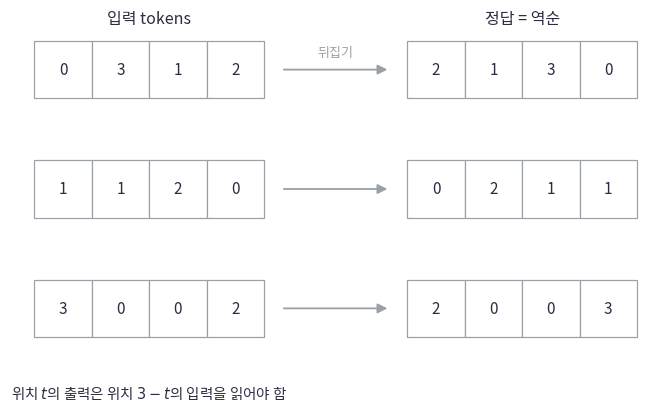

In [33]:
plot_reverse_examples(rev_inputs, rev_targets)

🔍 **확인** · 출력 위치 0은 입력 위치 3을, 출력 위치 3은 입력 위치 0을 그대로 복사해야 합니다. 같은 기호가 여러 번 나오는 둘째·셋째 예처럼 토큰 값만으로는 위치를 알 수 없으므로, 위치 표가 있어야 "몇 번째인가"를 읽습니다.
아래는 Adam과 학습 루프입니다. 기울기는 06번처럼 전체 norm으로 clip합니다.

In [34]:
from itertools import product                              # 모든 토큰 조합을 만드는 데 씀 (아래 셀)

def adam_step(p, grads, state, step, lr=0.01):
    """Adam 갱신 (04번 6절)을 파라미터 사전의 모든 배열에. p를 제자리에서 바꾸고 state의 (m, v)를 갱신합니다.
    p, grads: 같은 키의 사전, state: 키 → (m, v), step: 1부터 세는 스텝 수."""
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]                      # 1차 모멘트
        v = 0.999 * v + 0.001 * grads[key] ** 2             # 2차 모멘트
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)   # 편향 보정 뒤 갱신
        state[key] = (m, v)

In [35]:
all_tokens = np.array(list(product(range(4), repeat=4)))                  # (256, 4): 기호 4종의 길이 4 조합 전부
order = np.random.default_rng(901).permutation(len(all_tokens))            # 섞어서
train_tokens, valid_tokens = all_tokens[order[:192]], all_tokens[order[192:]]   # (192, 4) 학습, (64, 4) 검증
train_targets, valid_targets = train_tokens[:, ::-1], valid_tokens[:, ::-1]     # 정답 = 뒤집은 열
assert set(map(tuple, train_tokens)).isdisjoint(set(map(tuple, valid_tokens))), "같은 토큰열이 학습·검증에 함께 들어가면 안 됩니다"
print("검산 통과: 학습 192개와 검증 64개의 토큰열이 겹치지 않습니다")

검산 통과: 학습 192개와 검증 64개의 토큰열이 겹치지 않습니다


In [36]:
# 쓰는 것: init_transformer, transformer_forward, transformer_backward, token_ce (4절) · adam_step (5절)
p = init_transformer()
state = {k: (np.zeros_like(v), np.zeros_like(v)) for k, v in p.items()}   # Adam 상태 (m, v)
rng_train = np.random.default_rng(902)
history = {"step": [], "train": [], "valid": []}
for step in range(801):
    if step % 80 == 0:                                                   # 1. 80스텝마다 같은 파라미터로 학습·검증 CE 기록
        train_logits, _ = transformer_forward(train_tokens, p)
        valid_logits, _ = transformer_forward(valid_tokens, p)
        history["step"].append(step)
        history["train"].append(token_ce(train_logits, train_targets)[0])
        history["valid"].append(token_ce(valid_logits, valid_targets)[0])
    if step == 800:
        break
    batch = rng_train.choice(len(train_tokens), 64, replace=False)       # 2. 미니배치 64개
    logits, cache = transformer_forward(train_tokens[batch], p)          # 3. forward → 손실 → backward
    loss, dlogits = token_ce(logits, train_targets[batch])
    grads = transformer_backward(dlogits, cache, p)
    norm = np.sqrt(sum(np.sum(g * g) for g in grads.values()))           # 4. 클리핑 (06번 3절) 뒤 갱신
    scale = min(1., 1. / (norm + 1e-12))
    adam_step(p, {k: g * scale for k, g in grads.items()}, state, step + 1)
print("파라미터", sum(v.size for v in p.values()))

파라미터 1384


In [37]:
# 쓰는 것: valid_logits, history, valid_targets, train_targets, train_tokens (앞 두 셀)
predictions = valid_logits.argmax(axis=-1)                               # (64, 4): 마지막 기록 시점의 검증 예측
token_accuracy = np.mean(predictions == valid_targets)                   # 위치별로 맞힌 비율
sequence_accuracy = np.mean(np.all(predictions == valid_targets, axis=1))   # 네 위치를 모두 맞힌 문장의 비율
print(f"학습 CE {history['train'][0]:.6f} → {history['train'][-1]:.6f}")
print(f"검증 CE {history['valid'][-1]:.6f}, 토큰 {token_accuracy:.1%}, 문장 {sequence_accuracy:.1%}")
print("입력 / 정답 / 예측")
for x, y, pred in zip(valid_tokens[:5], valid_targets[:5], predictions[:5]):
    print(x, "/", y, "/", pred)
assert token_accuracy > 0.95, "검증 토큰 정확도가 95%를 넘어야 합니다"
assert sequence_accuracy > 0.9, "검증 문장 정확도가 90%를 넘어야 합니다"
np.testing.assert_array_equal(train_targets, train_tokens[:, ::-1])   # 검산: 위 그림처럼 정답은 뒤집은 열

학습 CE 1.554663 → 0.000001
검증 CE 0.000002, 토큰 100.0%, 문장 100.0%
입력 / 정답 / 예측
[3 0 1 3] / [3 1 0 3] / [3 1 0 3]
[1 2 1 2] / [2 1 2 1] / [2 1 2 1]
[0 3 0 2] / [2 0 3 0] / [2 0 3 0]
[1 1 3 0] / [0 3 1 1] / [0 3 1 1]
[1 0 3 1] / [1 3 0 1] / [1 3 0 1]


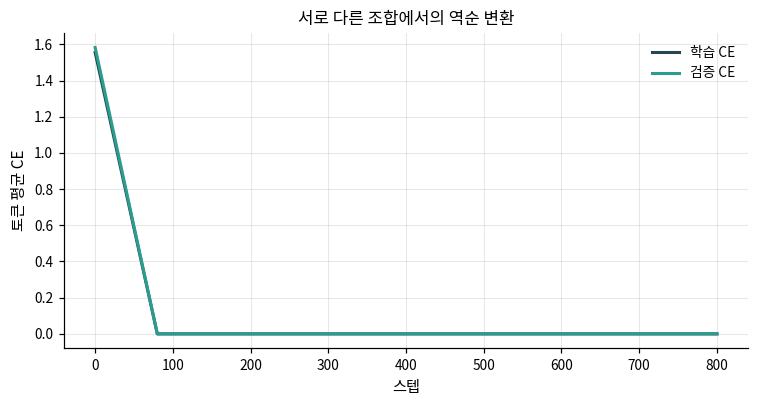

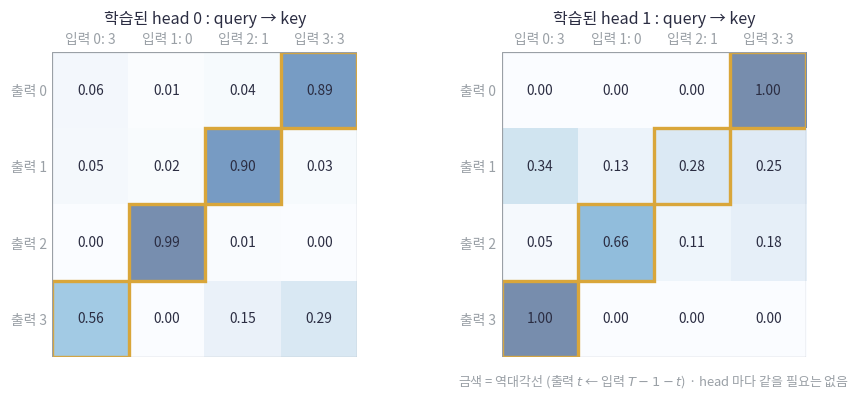

In [38]:
# 쓰는 것: transformer_forward (4절) · history, valid_tokens, p (5절 학습 셀). 그림용
plot_curves(history["step"], {"학습 CE": history["train"], "검증 CE": history["valid"]},
            title="서로 다른 조합에서의 역순 변환", ylabel="토큰 평균 CE")
_, trained_cache = transformer_forward(valid_tokens[:1], p)              # 검증 문장 하나
trained_attention = trained_cache[2][1][2][3][0]                         # (A, T, T): 학습된 두 head의 가중치
plot_trained_heads([trained_attention[h] for h in range(2)], valid_tokens[0])

🔍 **확인** · 검증 64개에서 토큰 정확도가 95%, 문장 정확도가 90%를 넘습니다. 아래 두 head의 가중치에서 금색 역대각선(출력 $t$가 입력 $T-1-t$를 읽는 자리)에 값이 몰리는지 보세요.
head가 모두 같은 역대각선 그림일 필요는 없습니다. 각 head의 결과를 출력 투영·잔차·FFN이 함께 쓰기 때문입니다. 실제 정답 예측과 가중치 그림을 별도로 확인하세요. 이 실험은 길이 4와 기호 4종의 조합 밖 성능까지 검사하지 않았습니다.

## 🔍 6. 위치 제거와 causal mask를 계산으로 확인하기

첫 검사는 **위치를 제거한 모델**의 순열 대응입니다. 토큰 순서를 바꾸면 출력도 그 순서로 바뀝니다. 현재 학습된 모델에서 위치를 제거한 성능은 참고 실험이며, 위치 없이 처음부터 훈련한 모델과의 공정한 비교는 아닙니다.

두 번째 검사는 **causal mask를 적용한 계산**의 정보 접근 범위입니다. 미래 토큰을 바꾸어도 과거 logits가 같아야 합니다. mask 자체가 GPT의 목적함수를 정하지는 않습니다. 다음 토큰을 target으로 정하는 학습과 한 토큰씩 생성하는 루프는 이후 노트북의 내용입니다.

In [39]:
# 쓰는 것: transformer_forward (4절) · valid_tokens, valid_targets, p (5절 학습 셀)
permutation = np.array([2, 0, 3, 1])
no_pos_logits, _ = transformer_forward(valid_tokens, p, use_positions=False)                 # 위치 표를 빼고
reordered_logits, _ = transformer_forward(valid_tokens[:, permutation], p, use_positions=False)   # 토큰 순서를 바꿔서
np.testing.assert_allclose(reordered_logits, no_pos_logits[:, permutation], atol=1e-10)   # 검산: 출력도 같은 순열로 바뀜 (순열 대응)
print("위치·mask 없는 모델의 순열 대응 검산 통과")
print("학습 후 위치만 제거한 토큰 정확도:", np.mean(no_pos_logits.argmax(axis=-1) == valid_targets))
T = 4
causal = np.arange(T)[None, :] <= np.arange(T)[:, None]     # (4, 4): causal mask
changed_tokens = valid_tokens[:2].copy()
changed_tokens[:, 2:] = (changed_tokens[:, 2:] + 1) % 4     # 위치 2·3(미래)의 토큰만 바꿈
past1, _ = transformer_forward(valid_tokens[:2], p, allowed=causal)
past2, _ = transformer_forward(changed_tokens, p, allowed=causal)
np.testing.assert_allclose(past1[:, :2], past2[:, :2], atol=1e-10)   # 검산: 과거 위치 0·1의 logits는 그대로
print("causal mask: 미래 변경에 대한 과거 logits 유지 검산 통과")

위치·mask 없는 모델의 순열 대응 검산 통과
학습 후 위치만 제거한 토큰 정확도: 0.5390625
causal mask: 미래 변경에 대한 과거 logits 유지 검산 통과


🔍 **확인** · 위치를 빼면 토큰을 섞은 만큼 출력도 똑같이 섞이고(순열 대응), 역순 변환 정확도는 크게 떨어집니다. causal mask를 씌우면 위치 2·3의 토큰을 바꿔도 위치 0·1의 logits가 그대로입니다.

## ✏️ 7. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · LayerNorm forward (1절)

`X` $(N,T,D)$, `gamma`, `beta`, `eps`에서 정규화 출력 `Y`를 만드는 두 줄을 채우세요. 평균은 써 두었습니다.

In [40]:
def exercise_layernorm(X, gamma, beta, eps=1e-5):
    """연습 A: LayerNorm forward. X: (N, T, D), gamma, beta: (D,) → Y: (N, T, D)."""
    mu = X.mean(axis=-1, keepdims=True)                     # (N, T, 1): 마지막 축의 평균
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: var = (X − mu)² 의 마지막 축 평균 (keepdims=True), Y = (X − mu) / sqrt(var + eps) * gamma + beta
    ### 힌트: 1절의 μ, v, x̂, y 네 식입니다. 통계는 마지막 축에서만 냅니다.
    raise NotImplementedError
    return Y

In [41]:
def check_layernorm_forward(candidate):
    """1절 손계산과 본문 layernorm_forward(γ ≠ 1, ε = 0.07)로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: ln_demo, ln_out (1절 손계산 셀) · layernorm_forward (1절)
    np.testing.assert_allclose(candidate(ln_demo[None], np.ones(4), np.zeros(4))[0], ln_out)          # 검산: 1절 손계산
    rng_c = np.random.default_rng(91)
    X_c, g_c, b_c = rng_c.normal(size=(2, 3, 4)), rng_c.normal(size=4), rng_c.normal(size=4)
    np.testing.assert_allclose(candidate(X_c, g_c, b_c, eps=0.07), layernorm_forward(X_c, g_c, b_c, eps=0.07)[0])   # 검산: 본문 함수
    print("LayerNorm forward: 손계산·layernorm_forward 와 일치합니다.")

run_check(check_layernorm_forward, exercise_layernorm, hint="var = ((X - mu) ** 2).mean(axis=-1, keepdims=True); Y = (X - mu) / np.sqrt(var + eps) * gamma + beta")

☐ exercise_layernorm: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: var = ((X - mu) ** 2).mean(axis=-1, keepdims=True); Y = (X - mu) / np.sqrt(var + eps) * gamma + beta


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
var = ((X - mu) ** 2).mean(axis=-1, keepdims=True)
Y = (X - mu) / np.sqrt(var + eps) * gamma + beta
```

</details>

### ✏️ 연습 B · head 나누기 (2절)

`X` $(N,T,D)$를 `(N, heads, T, D//heads)`로 바꾸는 한 줄을 채우세요. 값을 복사하지 않고 축만 다시 읽습니다.

In [42]:
def exercise_split_heads(X, heads):
    """연습 B: head 나누기. X: (N, T, D) → Xh: (N, heads, T, D/heads)."""
    N, T, D = X.shape
    assert D % heads == 0, "폭 D는 head 수로 나누어떨어져야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: (N, T, D) → reshape (N, T, heads, D//heads) → 축 순서를 (N, heads, T, D//heads) 로
    ### 힌트: .reshape(...).transpose(0, 2, 1, 3)
    raise NotImplementedError
    return Xh

In [43]:
def check_split_heads(candidate):
    """본문 split_heads·merge_heads와 2절 손계산의 head 1로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: head_X (2절 MHA 검산 셀) · split_heads, merge_heads (2절) · mh_X (2절 손계산 셀)
    Xh = candidate(head_X, 2)
    assert Xh.shape == (2, 2, 3, 2), f"모양은 (N, heads, T, d_h) = (2, 2, 3, 2)여야 하는데 {Xh.shape}입니다"
    np.testing.assert_array_equal(Xh, split_heads(head_X, 2))                                        # 검산: 본문 함수와 같음
    np.testing.assert_array_equal(merge_heads(Xh), head_X)                                           # 검산: 합치면 원래대로
    np.testing.assert_array_equal(candidate(mh_X[None], 2)[0, 1], mh_X[:, 2:])                      # 검산: head 1 = 뒤 두 열
    print("head 나누기: split_heads 와 일치하고 merge 로 되돌아옵니다.")

run_check(check_split_heads, exercise_split_heads, hint="Xh = X.reshape(N, T, heads, D // heads).transpose(0, 2, 1, 3)")

☐ exercise_split_heads: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: Xh = X.reshape(N, T, heads, D // heads).transpose(0, 2, 1, 3)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
Xh = X.reshape(N, T, heads, D // heads).transpose(0, 2, 1, 3)
```

</details>

### ✏️ 연습 C · FFN backward의 첫 줄 (3절)

상류 `dY` $(N,T,D)$, 활성 전 값 `Z` $(N,T,D_{ff})$, 둘째 가중치 `W2` $(D_{ff},D)$에서 `dZ`를 만드는 한 줄을 채우세요.

In [44]:
def exercise_ffn_dZ(dY, Z, W2):
    """연습 C: FFN backward의 첫 줄. dY: (N, T, D), Z: (N, T, D_ff), W2: (D_ff, D) → dZ: (N, T, D_ff)."""
    assert dY.shape[-1] == W2.shape[1], "dY의 폭은 W2의 열 수 D여야 합니다"
    assert Z.shape[-1] == W2.shape[0], "Z의 폭은 W2의 행 수 D_ff여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dZ = (dY 를 W2 의 전치로 되돌린 값) ⊙ ReLU 도함수 (Z > 0)
    ### 힌트: 3절 ffn_backward 의 첫 줄입니다.
    raise NotImplementedError
    return dZ

In [45]:
def check_ffn_dZ(candidate):
    """본문 ffn_backward의 dX와 ReLU가 닫힌 자리로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: ffn_forward, ffn_backward (3절)
    rng_c = np.random.default_rng(93)
    X_c = rng_c.normal(size=(2, 3, 4))
    p_c = {"W1": rng_c.normal(size=(4, 6)), "b1": rng_c.normal(size=6), "W2": rng_c.normal(size=(6, 4)), "b2": np.zeros(4)}
    F_c, cache_c = ffn_forward(X_c, p_c)
    dY_c = rng_c.normal(size=F_c.shape)
    dZ_c = candidate(dY_c, cache_c[1], p_c["W2"])                                                    # 캐시의 Z
    np.testing.assert_allclose(dZ_c @ p_c["W1"].T, ffn_backward(dY_c, cache_c, p_c)[0])              # 검산: dX = dZ @ W1ᵀ가 본문과 같음
    assert np.all(dZ_c[cache_c[1] <= 0] == 0), "ReLU가 닫힌 자리(Z ≤ 0)의 dZ는 0이어야 합니다"
    print("FFN dZ: ffn_backward 와 일치합니다.")

run_check(check_ffn_dZ, exercise_ffn_dZ, hint="dZ = (dY @ W2.T) * (Z > 0)")

☐ exercise_ffn_dZ: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dZ = (dY @ W2.T) * (Z > 0)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dZ = (dY @ W2.T) * (Z > 0)
```

</details>

### ✏️ 연습 D · embedding 표의 기울기 (4절)

정수 토큰 `tokens` $(N,T)$와 블록 입력의 기울기 `dX` $(N,T,D)$에서 표의 기울기 `dE` $(V,D)$를 누적하는 한 줄을 채우세요. 같은 토큰이 여러 번 나오면 모두 더해야 합니다.

In [46]:
def exercise_embedding_grad(tokens, dX, vocab):
    """연습 D: embedding 표의 기울기. tokens: (N, T) 정수, dX: (N, T, D) → dE: (vocab, D)."""
    dE = np.zeros((vocab, dX.shape[-1]))                    # (V, D): 누적할 자리
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: tokens 가 가리키는 dE 의 행에 dX 를 누적 (반복 토큰도 전부 더함)
    ### 힌트: np.add.at(dE, tokens, dX). dE[tokens] += dX 는 반복 인덱스를 놓칩니다.
    raise NotImplementedError
    return dE

In [47]:
def check_embedding_grad(candidate):
    """같은 토큰이 세 번 나오는 손계산과 반복문으로 직접 누적한 값으로 검사합니다. 통과하면 메시지를 출력합니다."""
    dE_a = candidate(np.array([[1, 1, 1]]), np.array([[[1., 2.], [3., 4.], [-1., 1.]]]), 3)
    np.testing.assert_allclose(dE_a, [[0, 0], [3, 7], [0, 0]])                                       # 검산: 같은 토큰 세 번 → 합
    tokens_c = np.array([[0, 1, 0], [2, 1, 1]])
    dX_c = np.random.default_rng(99).normal(size=(2, 3, 4))
    ref = np.zeros((3, 4))
    for n in range(2):
        for t in range(3):
            ref[tokens_c[n, t]] += dX_c[n, t]                                                        # 반복문으로 직접 누적
    np.testing.assert_allclose(candidate(tokens_c, dX_c, 3), ref)                                    # 검산: 반복문과 같음
    print("embedding 기울기: 반복 토큰의 누적이 맞습니다.")

run_check(check_embedding_grad, exercise_embedding_grad, hint="np.add.at(dE, tokens, dX)")

☐ exercise_embedding_grad: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: np.add.at(dE, tokens, dX)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
np.add.at(dE, tokens, dX)
```

</details>

### 🔍 완성 예제 · 검사기가 잡는 오답과 반복 토큰의 누적

아래는 마지막 잔차의 항등 경로 `+dY`를 빼먹은 오답입니다. 3절의 검사기가 거부하는지 실행합니다. 이어서 같은 토큰이 세 번 나올 때 `np.add.at`이 세 기여를 모두 더하는지 봅니다.

> **코드** · `try: … except AssertionError: … else: …`: 검사기가 assert로 멈추면 `except`로 가고(오답을 잡은 것), 멈추지 않으면 `else`로 갑니다. 여기서는 오답이 **잡혀야** 정상이므로 `else`에서 일부러 오류를 냅니다.

In [48]:
def wrong_missing_residual(dY, cache, p):
    """일부러 틀린 블록 backward: 둘째 잔차의 항등 경로 +dY를 빼먹었습니다. 인자·반환은 block_backward와 같습니다."""
    # 쓰는 것: ffn_backward (3절) · layernorm_backward (1절) · mha_backward (2절)
    ln1, mha, ln2, ffn = cache
    dB, grads = ffn_backward(dY, ffn, p)
    dU, grads["gamma2"], grads["beta2"] = layernorm_backward(dB, ln2)  # +dY 누락 (맞는 식은 dU = dY + …)
    dA, mha_grads = mha_backward(dU, mha, p)
    grads.update(mha_grads)
    dx_norm, grads["gamma1"], grads["beta1"] = layernorm_backward(dA, ln1)
    return dU + dx_norm, grads

In [49]:
# 쓰는 것: check_block_backward (3절)
try:
    check_block_backward(wrong_missing_residual)
except AssertionError:
    print("의도적 오답 검출: 잔차의 항등 미분 누락")
else:
    raise AssertionError("검사기가 오답을 놓쳤습니다")
embedding_probe = np.zeros((3, 2))                          # (V, D): 표의 기울기 자리
ids = np.array([1, 1, 1])                                   # 같은 토큰 1이 세 번
contributions = np.array([[1., 2.], [3., 4.], [-1., 1.]])   # 세 자리의 기여
np.add.at(embedding_probe, ids, contributions)              # 세 기여를 모두 행 1에 더함
np.testing.assert_allclose(embedding_probe[1], [3, 7])      # 검산: 1 + 3 − 1, 2 + 4 + 1
print("반복 토큰의 embedding 미분 누적:", embedding_probe[1])

의도적 오답 검출: 잔차의 항등 미분 누락
반복 토큰의 embedding 미분 누적: [3. 7.]


### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** Attention·위치·FFN·정규화·잔차가 각각 담당하는 계산을 구분할 수 있나요? → 1–4절
- **수식:** LN의 평균·분산 경로와 두 잔차의 항등 미분을 직접 쓸 수 있나요? → 1·3절
- **구현:** head 축을 나누고 합치며, 반복 토큰의 embedding 미분을 누적할 수 있나요? → 2·4절
- **변형:** head 수를 2에서 1이나 4로 바꾸면 무엇이 바뀌고 무엇이 그대로인지(D=12에서 투영 파라미터 수는 그대로, head 폭·점수 스케일은 변함), 위치와 mask가 순열·정보 접근에 주는 효과를 검산할 수 있나요? → 2·5·6절

다음은 [10 GNN](10_gnn.ipynb)입니다. 읽을 위치를 점수가 아니라 그래프의 이웃 관계로 정합니다.

📎 [MHA·FFN·위치·원래 Transformer 구조](https://arxiv.org/abs/1706.03762), [Layer Normalization 원 논문](https://arxiv.org/abs/1607.06450)을 참고할 수 있습니다. 이번 모델은 교육용 한 블록이며 dropout·encoder-decoder cross-attention은 구현하지 않았습니다. decoder를 확장할 때는 self-attention에 더해 다른 원천의 K·V를 읽는 08의 cross-attention을 연결할 수 있습니다.